In [1]:
from typing import List,Literal,TypedDict
from pydantic import BaseModel,Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma,FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.output_parsers import PydanticOutputParser
from langchain_huggingface import HuggingFaceEmbeddings,HuggingFaceEndpoint,ChatHuggingFace
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

C:\Users\adarsh\AppData\Local\Temp\ipykernel_20972\1902584308.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\adarsh\OneDrive\Desktop\langraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
docs=PyPDFLoader(r"C:\Users\adarsh\OneDrive\Desktop\langraph\SELF-RAG\Imaginary_Company_Profile.pdf").load()

In [4]:
chunks=RecursiveCharacterTextSplitter(chunk_size=100,chunk_overlap=10).split_documents(docs)


In [5]:
for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","igone")

In [6]:
embedding=HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
vector_store=FAISS.from_documents(chunks,embedding)
retriever=vector_store.as_retriever(search_kwargs={'k':4})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3009.87it/s]


In [7]:
llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation',
    max_new_tokens=2048
)

model=ChatHuggingFace(llm=llm,streaming=True)

In [8]:
class State(TypedDict):

    retrieval_query:str
    rewrite_tries:int
    
    question:str
    need_retrieval:bool
    docs:List[Document]
    relevant_docs:List[Document]
    context:str
    answer:str

    issup:Literal["fully_supported","partially_supported","no_support"]
    evidence:str

    retries:int
    is_use:Literal["useful","not_used"]
    use_reason:str

In [9]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        ...,
        description="True if the external document are needed to answer reliably,else false"
    )

parser=PydanticOutputParser(pydantic_object=RetrieveDecision)
decide_retrieval_prompt=ChatPromptTemplate.from_messages(

    [
        (
            "system",
            "you decide whether retrieval is needed.\n"
                        "Return a JSON  object tht matches this schema:\n"
                        "{{'should_retrieve':bool}}\n\n"
                        "Guidelines:\n"
                        "-should_retireve=True if the answering requires specific facts,citations or info likley not in the model\n"
                        "should_retrieve=False for general explanations,definitions ore reasoning that does not need sources.\n"
                        "-if unsure ,choose true"
            
                        "{format_instructions}"
            

        ),
        ("human","question:{question}")
    ]
)

def decision_retrieve(state:State):
    template=decide_retrieval_prompt.invoke({
        "question":state["question"],
        "format_instructions":parser.get_format_instructions()
    })

    result=model.invoke(template)
    out=parser.parse(result.content)

    return{
        "need_retrieval":out.should_retrieve
    }




In [10]:
direct_generation_prompt=ChatPromptTemplate.from_messages(
    [
    (
        "system",
        "Answer the question using your general Knowledge.\n"
        "do Not assume acces to external document"
        "if you are ensure or the answer requires specific sources,say:\n"
        "I dont know based on my general Knowledge"
    ),
    ("human","question:{question}")
    ]

)

def generate_direct(state:State):

    template=direct_generation_prompt.invoke({"question":state["question"]})

    out=model.invoke(template)
    return{"answer":out.content}

In [11]:
def retrieve(state:State):
    question=state["retrieval_query"] or state["question"]
    return {"docs":retriever.invoke(question)}

In [12]:
class RelevanceDecision(BaseModel):
    is_relevant:bool=Field(
        ...,
        description="True if document helps answer the question,else false"
    )

parser2=PydanticOutputParser(pydantic_object=RelevanceDecision)

is_relevant_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Yoy are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant':boolean}}\n\n"
            "A document is relevant if it contains informations useful for answering the question."

            "{format_instructions}"

        ),
        (
            "human",
            "Question:{question}\n\n Document:{document}"
        )

    ]


)

def is_relevant(state:State):

    relevant_docs:List[Document]=[]


    for d in state["docs"]:
        prompt=is_relevant_prompt.invoke(
            {
                "question":state["question"],
                "document":d,
                "format_instructions":parser2.get_format_instructions()
            }
        )

        out=model.invoke(prompt)
        result=parser2.parse(out.content)

        if  result.is_relevant:
            relevant_docs.append(d)

    return {"relevant_docs":relevant_docs}


    

In [13]:
answer_relevent_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "generate a favaorable answer of the question based on the document given to you"
            "Note-use documen tto answer the question"
        ),
        ("human","question:{question}\n ducument:{document}")

    ]
)

def generate_from_context(state:State):

    question=state["question"]

    context="\n\n".join(d.page_content for d in state["relevant_docs"]).strip()

    template=answer_relevent_prompt.invoke(
        {
            "question":question,
            "document":context
        }
    )
    output=model.invoke(template)

    return{"answer":output.content,"context":context}

In [14]:
def no_answer_found(state:State):

    return {"answer":"no relevent answer is presentin the docs","context":""}

In [15]:
def route_after_relevant(state:State):

    if State["relevant_docs"] and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_answer_found"

In [16]:
def route_after_decide(state:State):
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [17]:
class IsSuPDecision(BaseModel):

    issup:Literal["fully_supported","partially_supported","no_support"]
    evidence:List[str]=Field(default_factory=list)

parser3=PydanticOutputParser(pydantic_object=IsSuPDecision)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."

            "{format_instructions}"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def is_sup(state:State):

    template=issup_prompt.invoke(
        {
            "question":state["question"],
            "answer":state["answer"],
            "context":state["context"],
            "format_instructions":parser3.get_format_instructions()
        }
    )
    out=model.invoke(template)

    result=parser3.parse(out.content)

    return{
        "issup":result.issup,
        "evidence":result.evidence
    }

In [18]:
revise_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT(quote-only answer):\n"
            "->dirrectt quote form the CONTEXT>\n"
            "-<direct quote form the COONTEXT>\n\n"
            "Rules\n"
            "-Use Only the CONTEXT\n"
            "-Do NOT add ant new words besides bullet dashes and the quotes themselves.\n"
            "-DO  NOT explain anything\n"
            "Do NOT say 'context','not mentioned','does not mention','not provided'\n"
            "DO NOT try to give your Knowledge rather then the DOCUMENT Knowledge to give the answer"
        ),
        (
            "human",
            "Question:{question}\n\n"
            "Current Answer:{answer}\n\n"
            "CONTEXT:{context}"
        )
    ]
)

def revise_answer(state:State):
   template=revise_prompt.invoke(
      {
         "question":state["question"],
         "answer":state["answer"],
         "context":state["context"]
      }
   )
   out=model.invoke(template)

   return{
      "answer":out.content,
      "retries":state["retries"]+1
   }

In [19]:
MAX_RETRIES=5

In [20]:
def route_after_issup(state:State):

    if state.get("issup") == "fully_supported":
        return "accept_answer"

    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"  # will go to is_use, then likely not_useful -> no_answer_found
    return "revise_answer"

In [21]:
def accept_answer(state:State):
    return{'answer':state["answer"]}

In [22]:
class IsUseDecision(BaseModel):
    isuse:Literal["useful","not_useful"]
    reason:str=Field(...,description="Short reason in 1 line.")


parser4=PydanticOutputParser(pydantic_object=IsUseDecision)
is_use_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
           "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

def is_use(state:State):

    template=is_use_prompt.invoke(
        {
            "question":state["question"],
            "answer":state["answer"],

            "format_instructions":parser4.get_format_instructions()
        }
    )

    out=model.invoke(template)

    result=parser4.parse(out.content)

    return{
        "isuse":result.isuse,
        "use_reason":result.reason
    }

In [23]:
class RewriteDecision(BaseModel):

    retrieval_query:str=Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs"
    )


parser5=PydanticOutputParser(pydantic_object=RewriteDecision)
rewrite_for_retrieval_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NovaTech, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NovaTech Solutions Pvt. plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NovaTech Solutions free trial duration trial period plans'}}\n\n"
            "Q: 'What is NovaTech Solutions refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"


            "{format_instructions}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)


def rewrite_question(state:State):

    template=rewrite_for_retrieval_prompt.invoke(
        {
            "question":state["question"],
            "retrieval_query":state["retrieval_query"],
            "answer":state["answer"],
            "format_instructions":parser5.get_format_instructions()

        }
    )
    out=model.invoke(template)
    result=parser5.parse(out.content)

    return{
        "retrieval_query":result.retrieval_query,
        "rewrite_tries":state["rewrite_tries"]+1

    }


In [24]:
MAX_REWRITE_TRIES=5

In [25]:
def route_after_isuse(state:State):
    if state["isuse"]=="useful":
        return "finalize"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [29]:
g=StateGraph(State)
g.add_node("decision_retrieve",decision_retrieve)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)
g.add_node("is_relevant",is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_answer_found",no_answer_found)
g.add_node("is_sup",is_sup)
g.add_node("revise_answer",revise_answer)
g.add_node("accept_answer",accept_answer)
g.add_node("is_use",is_use)
g.add_node("rewrite_question",rewrite_question)

g.add_edge(START,"decision_retrieve")
g.add_conditional_edges(
    "decision_retrieve",
    route_after_decide,
    {
        "retrieve":"retrieve",
        "generate_direct":"generate_direct"
    }

)
g.add_edge("retrieve","is_relevant")
g.add_conditional_edges(
    "is_relevant",
    route_after_relevant,
    {
        "generate_from_context":"generate_from_context",
        "no_answer_found":"no_answer_found"
    }

)
g.add_edge("generate_from_context","is_sup")
g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {"accept_answer":"accept_answer","revise_answer":"revise_answer"}
)
g.add_edge("revise_answer","is_sup")
g.add_edge("accept_answer","is_use")
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {'finalize':END,"rewrite_question":"rewrite_question","no_answer_found":"no_answer_found"}

)
g.add_edge("rewrite_question","retrieve")
g.add_edge("no_answer_found",END)
#g.add_edge("no_answer_found",END)
g.add_edge("generate_direct",END)



In [30]:
app=g.compile()

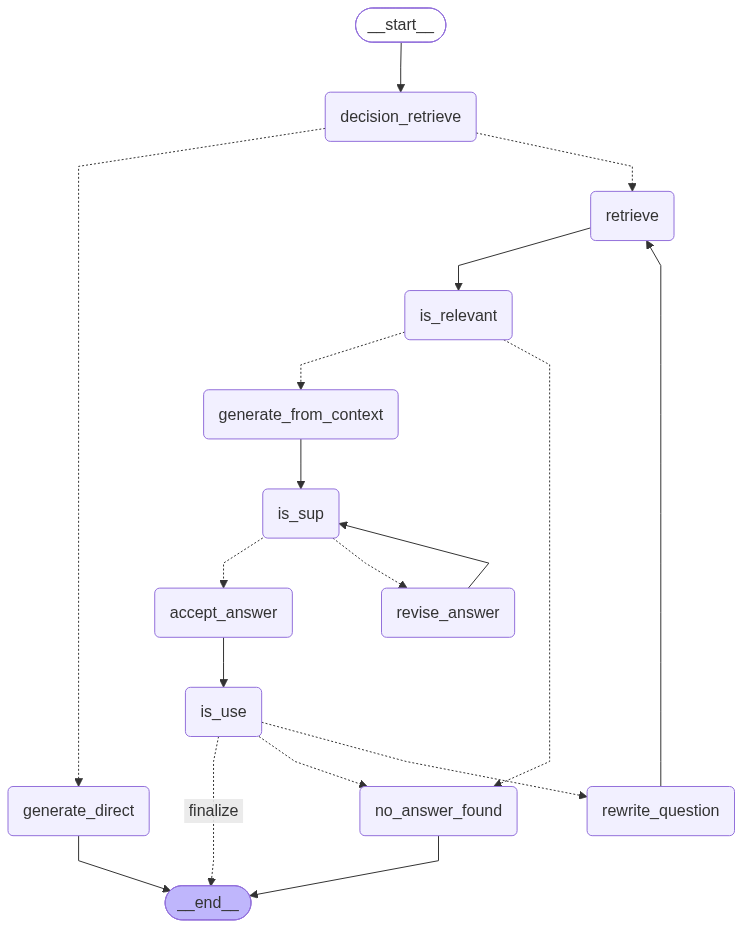

In [31]:
app